In [4]:
from functools import partial

import numpy as np

import torch
from torch import nn

from matplotlib import pyplot as plt

import sys
sys.path.append('../..')
sys.path.append('.')

from ansatz_utils.neural_networks import MLP
from ansatz_utils.permutation_actions import all_transpositions


%matplotlib inline

In [5]:
def make_transpositions(_x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    *size, d, n = _x.shape
    at = all_transpositions(_x.shape[-2], _x.device).unsqueeze(0).unsqueeze(-1)
    for i in range(len(size)-1):
        at = at.unsqueeze(2)
    
    shaped_input = _x.clone().unsqueeze(1)
    trans_input = torch.take_along_dim(shaped_input, at, -2)
    # print(shaped_input.shape, trans_input.shape, _x.shape)
    return shaped_input, trans_input
    

def nl_wso(function: nn.Module, _input: torch.Tensor) -> torch.Tensor:    
    si, ti = make_transpositions(_input)

    f1 = function(si)
    f2 = function(ti)

    f_out = (f1.sign() * torch.sqrt(0.5 * f1.abs() * (f1 - f2).abs().min(dim=1, keepdims=True)[0])).mean(dim=1)
    
    return f_out


def l_wso(function: nn.Module, _input: torch.Tensor) -> torch.Tensor:    
    si, ti = make_transpositions(_input)


    w = (si - ti).norm(dim=(-2, -1))
    ws = w.sum(dim=1, keepdims=True)

    W = torch.where()
    
    

    f1 = function(si)
    f2 = function(ti)

    f_out = (f1.sign() * torch.sqrt(0.5 * f1.abs() * (f1 - f2).abs().min(dim=1, keepdims=True)[0])).mean(dim=1)
    
    return f_out

In [248]:
def prod_all_but_one(X: torch.Tensor) -> torch.Tensor:
    size = X.size(-1)
    if size == 1:
        return torch.ones_like(X)
    return torch.cat([X[..., :i].prod(-1, True) * X[..., i+1:].prod(-1, True) for i in range(size)], dim=-1)

In [278]:
xx = (xs - xt).norm(dim=(-2, -1))

prod_all_but_one(xx) / (prod_all_but_one(xx).sum() + xx.prod())

tensor([[0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0.0025],
        [0

In [179]:
(1/xx).sum() + 1

tensor(inf, dtype=torch.float64)

In [273]:
N = 1000
u, l = 10, -10
X, Y = np.mgrid[l:u, l:u]
x = np.vstack(list(map(np.ravel, [X, Y]))).T[..., None]

x = np.stack([x, x[:, ::-1]], axis=-2)[..., 0]
x = torch.tensor(x, dtype=torch.float64)#.T.reshape(-1, 2, 2))
print(torch.prod(x))

# det = torch.det(Q).unsqueeze(1)
# Q[:, 0] = torch.where(det < 0, -Q[:, 0], Q[:, 0] )
#x = torch.matmul(x, Q)
#x = torch.matmul(Q.transpose(2, 1), x)

xs, xt = make_transpositions(x)
xx = (xs - xt).norm(dim=(-2, -1)).min(dim=1)[0].detach().numpy() / N

tensor(0., dtype=torch.float64)


In [149]:
f = nn.Sequential(nn.Flatten(-2, -1), MLP(4, 1, [32, 16], device=x.device, activation='tanh'))
nlws_f = partial(nl_wso, f)

In [150]:
p1 = f(x).detach().numpy().reshape(N, N).T
p2 = nlws_f(x).detach().numpy().reshape(N, N).T
p3 = xx.reshape(N, N).T

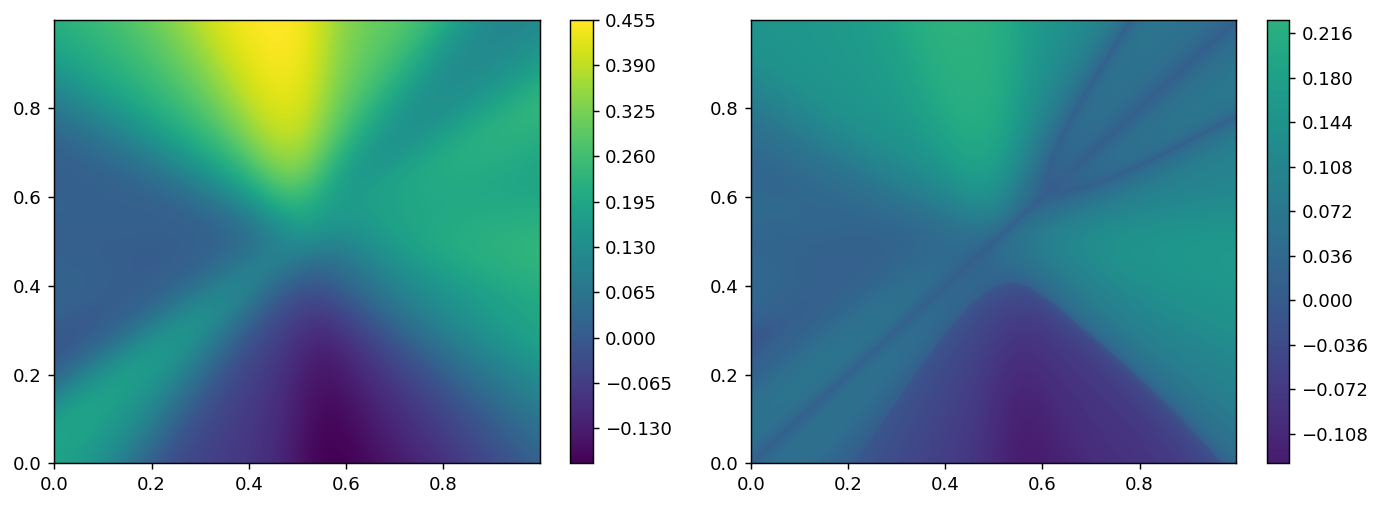

In [151]:
plt.figure(figsize=(16, 4), dpi=130)

plt.subplot(1, 3, 1)
cmap =plt.contourf(X, Y, p1, vmin=min(p1.min(), p2.min()), vmax=max(p1.max(), p2.max()), levels=300)
plt.colorbar(cmap)


#plt.subplot(2, 2, 2)
#cmap = plt.contourf(X, Y, p3, vmin=min(p1.min(), p2.min(), 0), vmax=max(p1.max(), p2.max(), p3.max()), levels=50)
#plt.colorbar(cmap)

plt.subplot(1, 3, 2)
cmap = plt.contourf(X, Y, p2, vmin=min(p1.min(), p2.min()), vmax=max(p1.max(), p2.max()), levels=300)
plt.colorbar(cmap)


plt.tight_layout()
plt.show()

In [153]:
np.isclose(p1, 0).sum() / N, np.isclose(p2, 0).sum() / N

(0.0, 1.0)